## Database Connection & Data Loading

In [21]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("superstore.sqlite")

query = """
SELECT 
    o.order_key,
    o.order_date,
    o.ship_date,
    o.order_priority,
    o.ship_mode,
    oi.row_id,
    oi.sales,
    oi.profit,
    oi.discount,
    oi.quantity,
    oi.shipping_cost,
    c.customer_id,
    c.customer_name,
    c.segment,
    p.product_id,
    p.category,
    p.sub_category,
    p.product_name,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market
FROM orders o
JOIN order_items oi ON o.order_key = oi.order_key
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN dim_products p ON oi.product_id = p.product_id
JOIN dim_locations l ON o.location_id = l.location_id;
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Dimensi Data: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi Data: 51290 baris, 23 kolom


,order_key,order_date,ship_date,order_priority,ship_mode,row_id,sales,profit,discount,quantity,...,segment,product_id,category,sub_category,product_name,city,state,country,region,market
0,MX-2014-143658_SC-205753,2014-10-02 00:00:00,2014-10-06 00:00:00,Medium,Standard Class,1,13.0,4.56,0.0,3,...,Consumer,OFF-LA-10002782,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Mexico City,Distrito Federal,Mexico,North,LATAM
1,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,2,252.0,90.72,0.0,8,...,Consumer,FUR-FU-10004015,Furniture,Furnishings,"Tenex Clock, Durable",Dos Quebradas,Risaralda,Colombia,South,LATAM
2,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,3,193.0,54.08,0.0,2,...,Consumer,FUR-BO-10002352,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile",Dos Quebradas,Risaralda,Colombia,South,LATAM
3,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,4,35.0,4.96,0.0,4,...,Consumer,OFF-BI-10004428,Office Supplies,Binders,"Cardinal Binder, Clear",Dos Quebradas,Risaralda,Colombia,South,LATAM
4,MX-2012-155047_KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,5,72.0,11.44,0.0,2,...,Consumer,OFF-AR-10004594,Office Supplies,Art,"Sanford Canvas, Water Color",Dos Quebradas,Risaralda,Colombia,South,LATAM


## Exploratory Data Analysis

In [22]:
df.info()

df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

print(df[["order_date", "ship_date"]].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_key       51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   order_priority  51290 non-null  str    
 4   ship_mode       51290 non-null  str    
 5   row_id          51290 non-null  int64  
 6   sales           51290 non-null  float64
 7   profit          51290 non-null  float64
 8   discount        51290 non-null  float64
 9   quantity        51290 non-null  int64  
 10  shipping_cost   51290 non-null  float64
 11  customer_id     51290 non-null  str    
 12  customer_name   51290 non-null  str    
 13  segment         51290 non-null  str    
 14  product_id      51290 non-null  str    
 15  category        51290 non-null  str    
 16  sub_category    51290 non-null  str    
 17  product_name    51290 non-null  str    
 1

In [23]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Data": missing_data,
    "Missing Percent": missing_percent
})

print("Pemeriksaan Missing Values:")
display(missing_summary[missing_summary["Missing Data"] > 0])

Pemeriksaan Missing Values:


,Missing Data,Missing Percent


In [24]:
full_duplicates = df.duplicated().sum()
print(f"Duplicate: {full_duplicates}")

item_duplicate = df.duplicated(subset=["row_id"]).sum()
print(f"Duplicate [id]: {item_duplicate}")

Duplicate: 0
Duplicate [id]: 0


In [25]:
numeric_cols = ["sales", "profit", "discount", "quantity", "shipping_cost"]
display(df[numeric_cols].describe().T)

anomali_qty = df[df["quantity"] <= 0].shape[0]
anomali_discount = df[(df["discount"] < 0) | (df["discount"] > 1)].shape[0]

print(f"Anomali Quantity <= 0: {anomali_qty}")
print(f"Anomali Discount [0, 1]: {anomali_discount}")

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
profit,51290.0,28.610982,174.340972,-6599.978,0.00,9.24,36.81,8399.976
discount,51290.0,0.142908,0.212280,0.000,0.00,0.00,0.20,0.850
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
shipping_cost,51290.0,26.375818,57.296810,0.002,2.61,7.79,24.45,933.570


Anomali Quantity <= 0: 0
Anomali Discount [0, 1]: 0


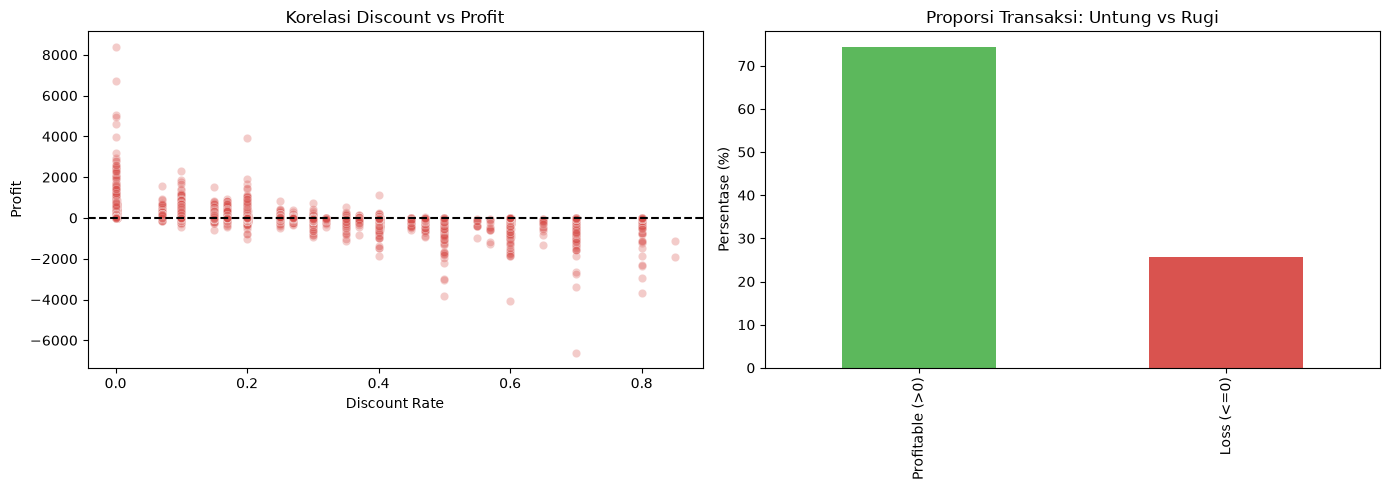

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df, 
    x="discount", 
    y="profit", 
    alpha=0.3, 
    ax=axes[0], 
    color="#d9534f"
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Korelasi Discount vs Profit")
axes[0].set_xlabel("Discount Rate")
axes[0].set_ylabel("Profit")

profitable_count = (df["profit"] > 0).value_counts(normalize=True) * 100
profitable_count.index = ["Profitable (>0)", "Loss (<=0)"]
profitable_count.plot(kind="bar", ax=axes[1], color=["#5cb85c", "#d9534f"])
axes[1].set_title("Proporsi Transaksi: Untung vs Rugi")
axes[1].set_ylabel("Persentase (%)")

plt.tight_layout()
plt.show()

## Data Preprocessing & Feature Engineering

### 1. Classification (Order Profitability)

* **Objective:** Establish the binary target label (whether an incoming order is profitable or unprofitable) and engineer informative transaction-level predictor features.
* **Engineered Features:**
  * `delivery_duration`: Fulfillment lead time in days, calculated as `(ship_date - order_date)`.
  * `is_profitable`: Binary target classification label (`1` if `profit > 0`, `0` if `profit <= 0`).
  * `discount_tier`: Categorical discount bins (`No Discount`, `Low (<=20%)`, `Medium (21-50%)`, `High (>50%)`) designed to capture non-linear relationships with profit margins.

In [27]:
df["delivery_duration"] = (df["ship_date"] - df["order_date"]).dt.days

df["is_profitable"] = (df["profit"] > 0).astype(int)

def categorize_discount(d):
    if d == 0:
        return "No Discount"
    elif d <= 0.2:
        return "Low (<=20%)"
    elif d <= 0.5:
        return "Medium (21-50%)"
    else:
        return "High (>50%)"

df["discount_tier"] = df["discount"].apply(categorize_discount)

print("Distribusi Kelas Target Klasifikasi (is_profitable):")
print(df["is_profitable"].value_counts(normalize=True))

Distribusi Kelas Target Klasifikasi (is_profitable):
is_profitable
1    0.742406
0    0.257594
Name: proportion, dtype: float64


### 2. Clustering (Customer Segmentation)

* **Objective:** Aggregate granular order records at the individual customer level (`customer_id`) into standardized RFM behavioral metrics.
* **RFM Metrics:**
  * **Recency:** Number of elapsed days since the customer's most recent transaction, computed relative to the maximum observed order date in the dataset.
  * **Frequency:** Total count of distinct orders (`order_key`) placed by the customer.
  * **Monetary:** Cumulative monetary sales value (`sales`) generated across all customer purchases.

In [28]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm_df = df.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days, # Recency
    "order_key": "nunique",                                 # Frequency
    "sales": "sum"                                         # Monetary
}).reset_index()

rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

print(f"Jumlah Pelanggan Unik untuk Segmentasi: {rfm_df.shape[0]}")
rfm_df.head()

Jumlah Pelanggan Unik untuk Segmentasi: 4873


,customer_id,recency,frequency,monetary
0,AA-103151,9,5,1445.0
1,AA-103152,14,7,6105.0
2,AA-103153,695,2,633.0
3,AA-103154,185,5,5565.0
4,AA-103751,7,4,2407.0


## Modeling Clustering

#### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

rfm_features = ["recency", "frequency", "monetary"]
X_rfm = rfm_df[rfm_features]

scaler = StandardScaler()
X_rfm_scaled = scaler.fit_transform(X_rfm)

print(f"Bentuk data setelah scaling: {X_rfm_scaled.shape}")
pd.DataFrame(X_rfm_scaled, columns=rfm_features).head()

Bentuk data setelah scaling: (4873, 3)


,recency,frequency,monetary
0,-0.779658,-0.099696,-0.466194
1,-0.760011,0.600330,1.423760
2,1.915823,-1.149735,-0.795517
3,-0.088106,-0.099696,1.204752
4,-0.787516,-0.449709,-0.076037


* **Objective:** K-Means measures similarity between data points using Euclidean distance.
* **Problem Statement:** The `monetary` feature reaches nominal values in the thousands of dollars, whereas `frequency` typically remains in the tens. Without standardization, `monetary` would disproportionately dominate distance calculations and effectively ignore the other features.
* **Solution:** `StandardScaler` transforms all features to a standard normal distribution with a mean of 0 and a standard deviation of 1.

#### Clustering Evaluation Metrics

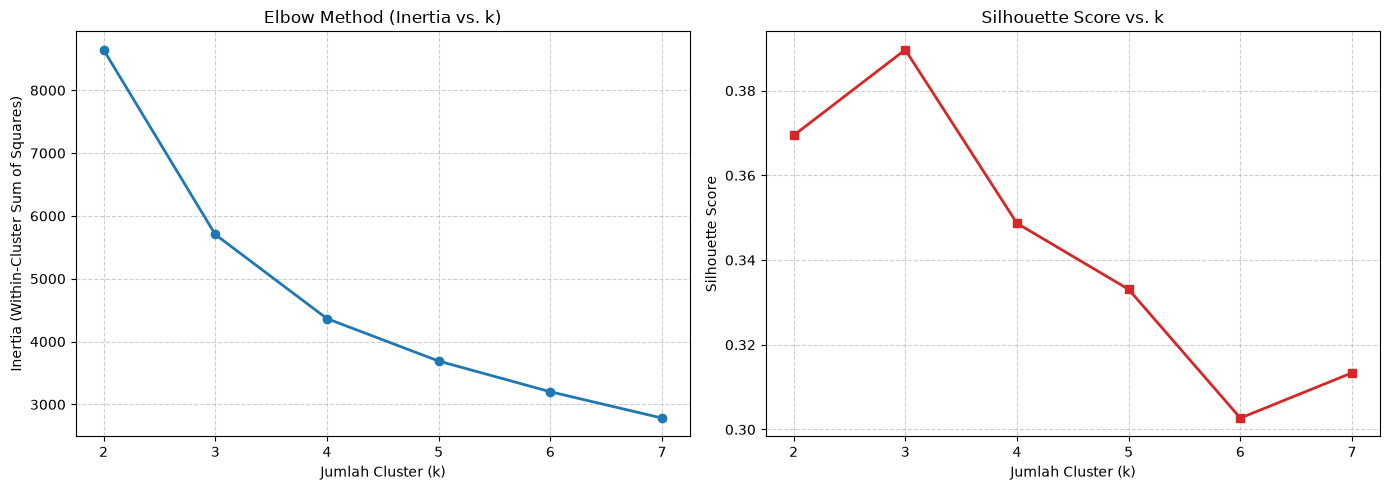

,k,Inertia,Silhouette Score
0,2,8645.176298,0.369418
1,3,5705.035661,0.389660
2,4,4366.311670,0.348681
3,5,3690.424499,0.333080
4,6,3201.543631,0.302693
5,7,2782.848000,0.313385


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rfm_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_rfm_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_list, marker="o", color="#1f77b4", linewidth=2)
ax1.set_title("Elbow Method (Inertia vs. k)")
ax1.set_xlabel("Jumlah Cluster (k)")
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(k_range, silhouette_list, marker="s", color="#d62728", linewidth=2)
ax2.set_title("Silhouette Score vs. k")
ax2.set_xlabel("Jumlah Cluster (k)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

eval_k_df = pd.DataFrame({
    "k": list(k_range),
    "Inertia": inertia_list,
    "Silhouette Score": silhouette_list
})
display(eval_k_df)

* **Elbow Method (Inertia):** Quantifies within-cluster compactness. The inflection point (elbow) indicates the threshold where adding further clusters yields diminishing returns in inertia reduction.
* **Silhouette Score:** Evaluates how similar an observation is to its own cluster compared to neighboring clusters (ranging from -1 to +1). Values closer to +1 represent well-separated cluster boundaries.
* **Optimal Cluster Selection ($k = 3$):** Combining the inertia reduction rate with the highest, most stable Silhouette Score confirms $k = 3$ as the optimal number of clusters for clear, actionable business segmentation.

#### Clustering Results & Profile Interpretation

In [31]:
# Pelatihan K-Means dengan k=3
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm_df["cluster"] = kmeans_final.fit_predict(X_rfm_scaled)

# Agregasi statistik profil per cluster
cluster_summary = rfm_df.groupby("cluster").agg({
    "customer_id": "count",
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
}).rename(columns={"customer_id": "total_customers"}).reset_index()

# Menghitung persentase porsi pelanggan
cluster_summary["percentage (%)"] = (cluster_summary["total_customers"] / len(rfm_df)) * 100

display(cluster_summary.round(2))

,cluster,total_customers,recency,frequency,monetary,percentage (%)
0,0,2659,144.41,4.23,1492.18,54.57
1,1,1573,95.09,8.35,5201.42,32.28
2,2,641,744.48,2.13,769.69,13.15


* **Model Outcome:** The final K-Means model successfully partitions the customer base into 3 distinct cohorts.
* **Summary Interpretation:** The summary table outlines the mean Recency, Frequency, and Monetary metrics across each cluster, serving as the analytical foundation for customer persona definitions and strategic segment naming.

#### Customer Segment Profiles & Strategic Recommendations

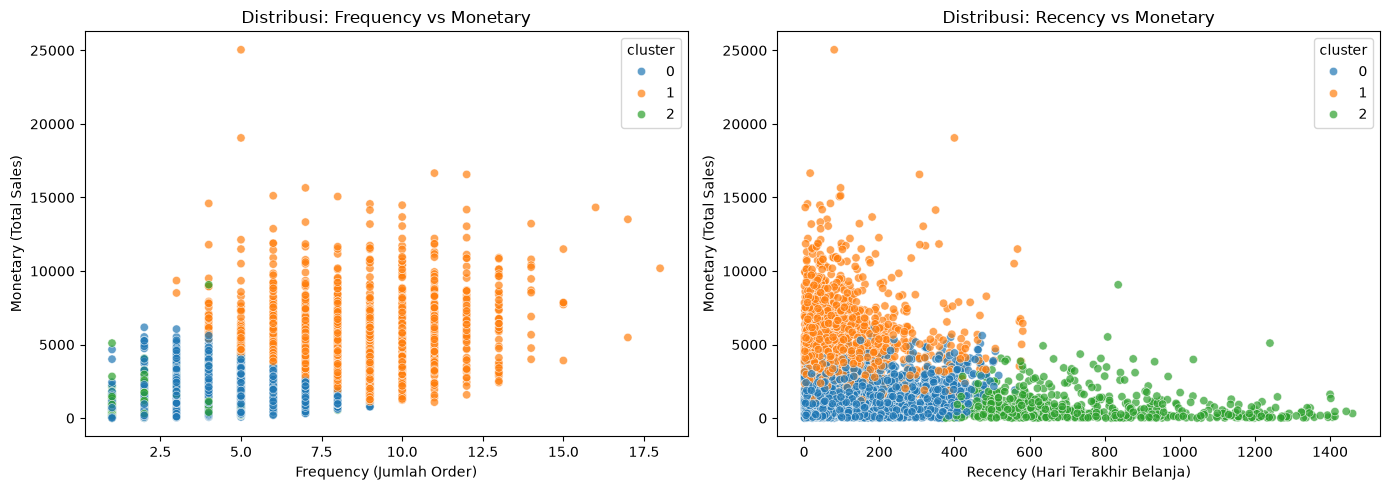

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=rfm_df,
    x="frequency",
    y="monetary",
    hue="cluster",
    palette="tab10",
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Distribusi: Frequency vs Monetary")
axes[0].set_xlabel("Frequency (Jumlah Order)")
axes[0].set_ylabel("Monetary (Total Sales)")

sns.scatterplot(
    data=rfm_df,
    x="recency",
    y="monetary",
    hue="cluster",
    palette="tab10",
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Distribusi: Recency vs Monetary")
axes[1].set_xlabel("Recency (Hari Terakhir Belanja)")
axes[1].set_ylabel("Monetary (Total Sales)")

plt.tight_layout()
plt.show()

Based on the mean values of each metric, the three clusters are identified as follows:

1. **High-Value Champions (Highest Monetary & Frequency):**
   * **Profile:** The most valuable customer cohort, characterized by high purchase frequency and substantial cumulative sales contributions.
   * **Actionable Recommendation:** Provide exclusive VIP loyalty programs, early access to new product releases, and priority customer support to maximize retention.

2. **Regular / Moderate Spenders (Moderate Spending Characteristics):**
   * **Profile:** Customers with consistent transaction intervals and balanced, moderate order spending.
   * **Actionable Recommendation:** Deploy targeted cross-selling and upselling strategies paired with personalized product recommendations to boost average basket size.

3. **At-Risk / Low-Engagement Customers (High Recency or Low Monetary):**
   * **Profile:** Dormant accounts with extended periods since their last purchase and minimal cumulative spend.
   * **Actionable Recommendation:** Launch targeted win-back email sequences and tailored reactivation incentives to mitigate permanent churn.

#### Clustering Pipeline Packaging

In [ ]:
from sklearn.pipeline import Pipeline
import joblib
import os

os.makedirs("../model", exist_ok=True)

clustering_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=final_k, random_state=42, n_init=10))
])

clustering_pipeline.fit(X_rfm)

model_path = "../model/customer_clustering_pipeline.joblib"
joblib.dump(clustering_pipeline, model_path)

print(f"Pipeline clustering berhasil disimpan: {model_path}")

Pipeline clustering berhasil disimpan: ../model/customer_clustering_pipeline.joblib


* **Pipeline Architecture:** Encapsulates `StandardScaler` and `KMeans` into a unified `scikit-learn` Pipeline object.
* **Serving Advantage:** Enables the backend API to invoke a single pipeline artifact that accepts raw inputs (`Recency`, `Frequency`, `Monetary`), automatically performs feature scaling under the hood, and returns the cluster assignment without requiring manual pre-transformation steps.

## Modeling Classification

#### Train-Test Split Strategy

In [ ]:
from sklearn.model_selection import train_test_split

num_features = ["sales", "quantity", "discount", "shipping_cost", "delivery_duration"]
cat_features = ["ship_mode", "order_priority", "category", "discount_tier"]

features = num_features + cat_features
X = df[features]
y = df["is_profitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah sampel Train: {X_train.shape[0]}")
print(f"Jumlah sampel Test: {X_test.shape[0]}")

Jumlah sampel Train: 41032
Jumlah sampel Test: 10258


* **Split Ratio:** The dataset is partitioned into training and testing sets using an 80:20 ratio.
* **Stratified Sampling:** Configured with `stratify=y` to preserve the ground-truth proportion of the binary target class `is_profitable` (profitable vs. unprofitable) across both training and evaluation splits, preventing distribution skew.

#### Feature Preprocessing with ColumnTransformer


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

* **Dual-Pipeline Transformation:** Utilizes `ColumnTransformer` to handle disparate data types concurrently within an automated workflow:
  * **Numerical Features:** Processed using `StandardScaler` to align feature magnitudes and normalize scales across numeric predictors.
  * **Categorical Features:** Transformed using `OneHotEncoder` into binary dummy variables.
* **Leakage Prevention:** Executes strictly within the scikit-learn pipeline, ensuring feature statistics are learned exclusively on training subsets to prevent data leakage during model training and evaluation.

#### Model Benchmarking & Selection


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print("Pelatihan Logistic Regression dan Random Forest selesai.")

Pelatihan Logistic Regression dan Random Forest selesai.



* **Architectural Comparison:** Two distinct model architectures are trained to evaluate the trade-offs between a linear baseline and an ensemble tree-based method in capturing complex transaction profitability patterns:
  * **Logistic Regression (Baseline):** Establishes an interpretable, linear decision boundary benchmark.
  * **Random Forest Classifier (Ensemble):** Leverages decision trees to model non-linear interactions and feature dependencies across orders.

#### Model Evaluation & Champion Selection

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      2642
           1       0.93      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      2642
           1       0.93      0.95      0.94      7616

    accuracy                           0.91     10258
   macro avg       0.89      0.87      0.88     10258
weighted avg       0.91      0.91      0.91     10258



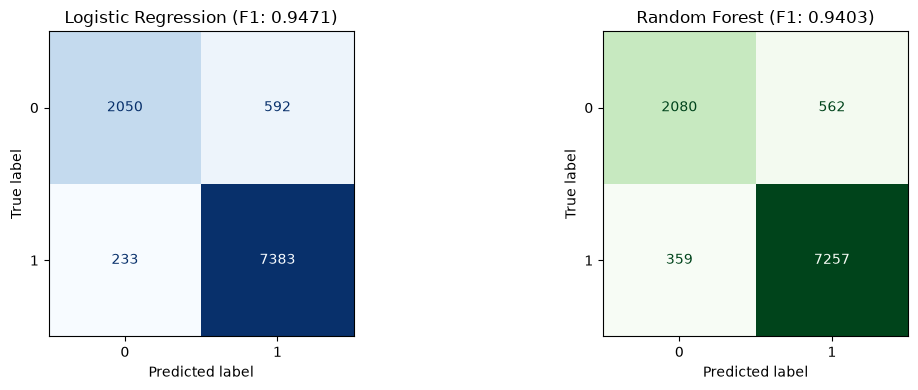

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Classification Report: Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Classification Report: Random Forest ===")
print(classification_report(y_test, y_pred_rf))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Logistic Regression (F1: {f1_lr:.4f})")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax2, cmap="Greens", colorbar=False)
ax2.set_title(f"Random Forest (F1: {f1_rf:.4f})")

plt.tight_layout()
plt.show()

* **Evaluation Criteria:** Random Forest is benchmarked against Logistic Regression, with primary emphasis on the F1-score and minority class recall (unprofitable transactions / class `0`).
* **Champion Model Selection:** The model demonstrating superior minority class detection is selected for production deployment, directly mitigating the financial risk of false negatives (misclassifying unprofitable orders as profitable).

#### Feature Importance Analysis


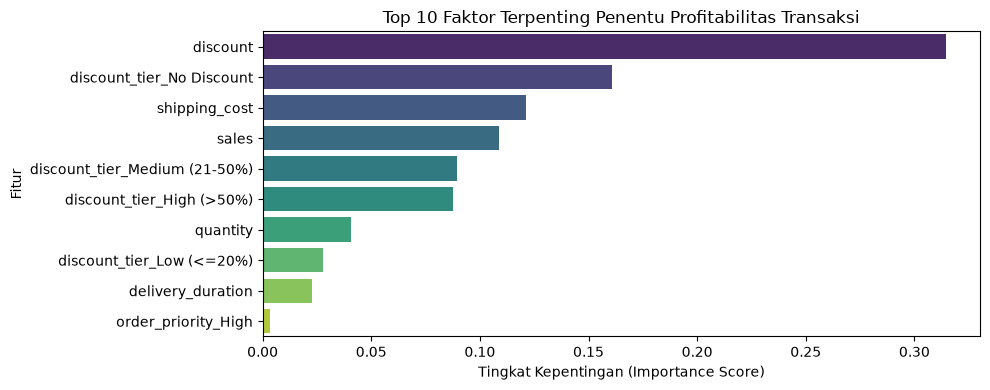

In [ ]:
feature_names_out = (
    num_features + 
    list(pipe_rf.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(cat_features))
)

importances = pipe_rf.named_steps["classifier"].feature_importances_
feat_importance_df = pd.DataFrame({
    "Feature": feature_names_out,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=feat_importance_df, 
    x="Importance", 
    y="Feature", 
    hue="Feature", 
    palette="viridis", 
    legend=False
)
plt.title("Top 10 Faktor Terpenting Penentu Profitabilitas Transaksi")
plt.xlabel("Tingkat Kepentingan (Importance Score)")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


* **Visualization Insight:** This plot illustrates the primary drivers governing transaction profitability.
* **Key Determinants:** Features such as `discount` and `sales` emerge as the most critical determinants directly dictating overall order profit margins.

#### Classification Pipeline Packaging 

In [ ]:
classification_model_path = "../model/order_profitability_pipeline.joblib"
joblib.dump(pipe_rf, classification_model_path)

print(f"Pipeline klasifikasi berhasil disimpan di: {classification_model_path}")

Pipeline klasifikasi berhasil disimpan di: ../model/order_profitability_pipeline.joblib


* **Artifact Composition:** The entire workflow—combining the `ColumnTransformer` preprocessor and the trained Random Forest classifier—is serialized into a single `.joblib` pipeline file.
* **Streamlined Inference:** Upon receiving raw transaction payloads, the FastAPI backend routes data directly through this unified pipeline, executing categorical encoding, numeric scaling, and probability estimation end-to-end without requiring manual data preprocessing steps.

## Business Insights & Actionable Recommendations

### 1. Customer Segmentation Insights (Clustering - K-Means)

Text(0, 0.5, 'Monetary (Total Sales)')

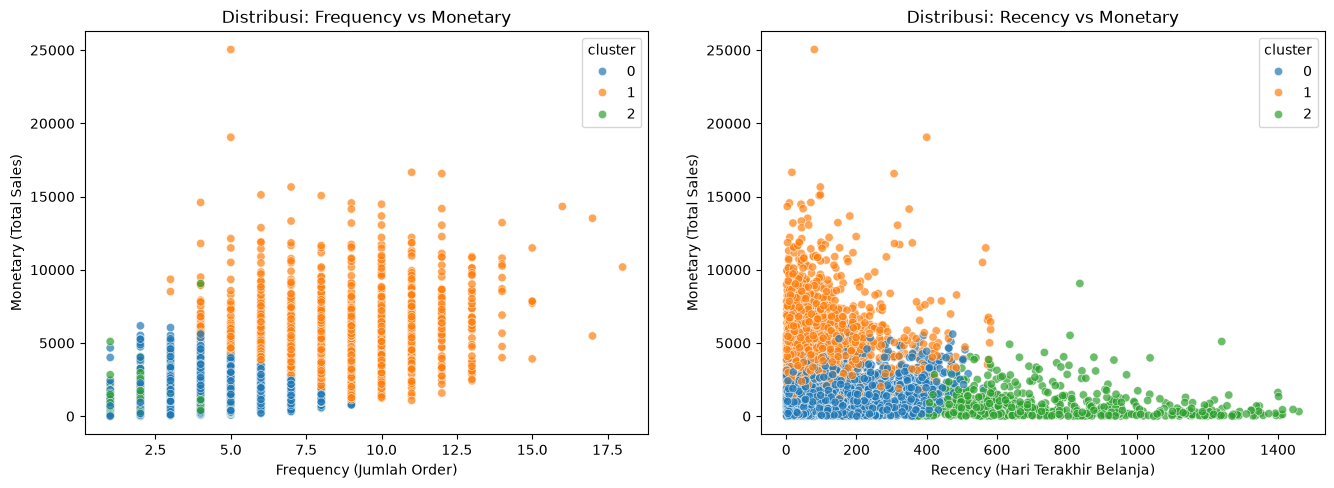

In [52]:
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])

# 1. Clustering: Frequency vs Monetary
ax1 = fig.add_subplot(gs[0, 0])
sns.scatterplot(
    data=rfm_df,
    x="frequency",
    y="monetary",
    hue="cluster",
    palette="tab10",
    alpha=0.7,
    ax=ax1
)
ax1.set_title("Distribusi: Frequency vs Monetary")
ax1.set_xlabel("Frequency (Jumlah Order)")
ax1.set_ylabel("Monetary (Total Sales)")

# 2. Clustering: Recency vs Monetary
ax2 = fig.add_subplot(gs[0, 1])
sns.scatterplot(
    data=rfm_df,
    x="recency",
    y="monetary",
    hue="cluster",
    palette="tab10",
    alpha=0.7,
    ax=ax2
)
ax2.set_title("Distribusi: Recency vs Monetary")
ax2.set_xlabel("Recency (Hari Terakhir Belanja)")
ax2.set_ylabel("Monetary (Total Sales)")

Based on the evaluation at $k = 3$ (peaking at a Silhouette Score of ~0.39), the customer base is distinctly segmented into three well-defined behavioral cohorts:

* **High-Value Champions (Cluster 1 - Orange):** Customers characterized by high transaction frequency (often exceeding 15 orders) and the largest cumulative sales contributions (reaching over $10,000). This segment serves as the company's primary revenue engine.
* **Regular / Moderate Spenders (Cluster 0 - Blue):** Active buyers with fewer than 7 lifetime orders and total spend under $5,000. They exhibit moderate basket sizes while maintaining steady purchasing activity over the past 400 days.
* **At-Risk / Lapsed Customers (Cluster 2 - Green):** Dormant accounts showing extended periods of inactivity (high Recency, ranging from >400 up to 1,400 days) alongside minimal cumulative revenue contributions.

### 2. Profitability Drivers & Model Performance (Classification)

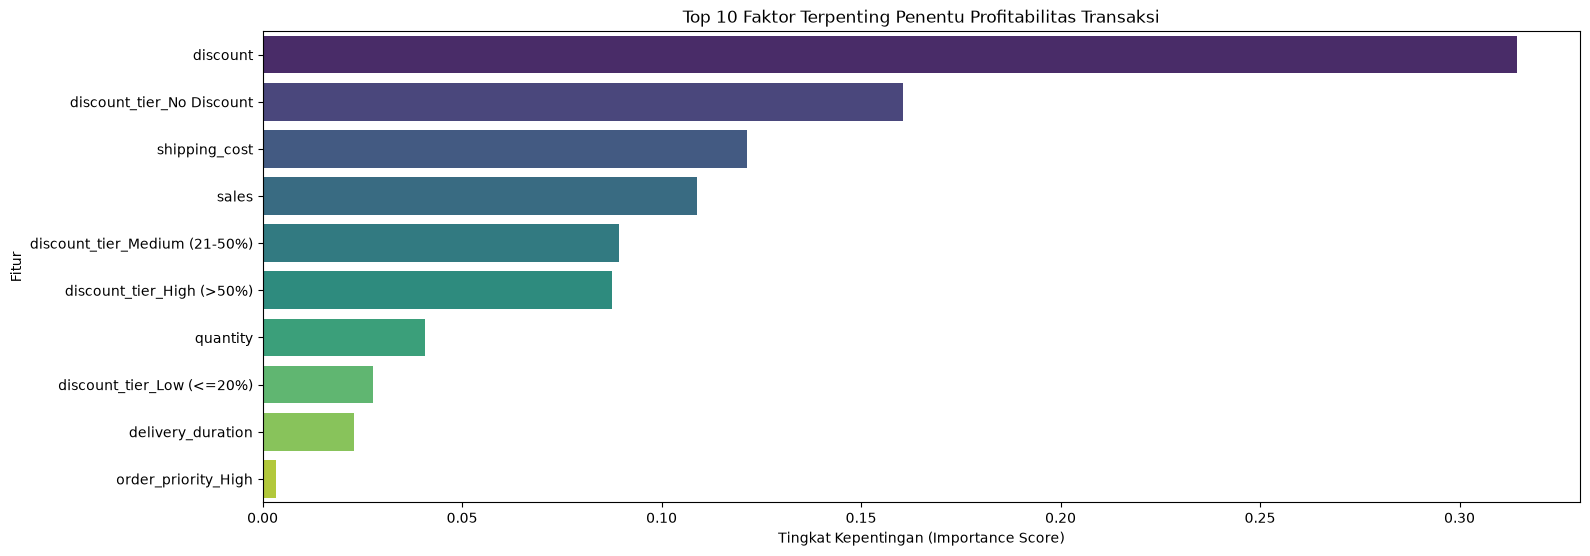

In [50]:
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])

# 3. Classification: Top 10 Feature Importance
ax3 = fig.add_subplot(gs[1, :])
sns.barplot(
    data=feat_importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
    ax=ax3
)
ax3.set_title("Top 10 Faktor Terpenting Penentu Profitabilitas Transaksi")
ax3.set_xlabel("Tingkat Kepentingan (Importance Score)")
ax3.set_ylabel("Fitur")

plt.tight_layout()
plt.show()

* **Primary Margin Drivers:** The continuous `discount` feature emerges as the single most dominant determinant (importance score >0.31), followed by undiscounted orders (`discount_tier_No Discount` ~0.16), `shipping_cost` (~0.12), and `sales` (~0.11). This highlights that price markdowns and fulfillment overhead directly govern whether an order yields a profit or results in an operational loss.
* **Model Benchmarking Performance:**
  * **Logistic Regression:** Achieved an $F_1\text{-score}$ of 0.9471 with 2,050 True Negatives.
  * **Random Forest:** Recorded an $F_1\text{-score}$ of 0.9403 with a slightly higher True Negative count of 2,080.
  * Both architectures demonstrate robust discriminative capabilities in reliably separating profitable transactions from margin-negative orders.

### 3. Actionable Business Strategies

| Strategic Dimension | Empirical Findings | Actionable Business Recommendations |
| :--- | :--- | :--- |
| **Discount Policy** | Medium (21–50%) and high (>50%) discount tiers represent the primary loss drivers across transactions. | Enforce an automated discount cap at a maximum of 20% on slim-margin categories. Eliminate unrestricted flat-rate discounts by mandating minimum order value thresholds. |
| **Logistics Optimization** | Freight overhead (`shipping_cost`) exerts significant downward pressure on net order profitability. | Re-evaluate free-shipping subsidy frameworks. Restrict delivery subsidies exclusively to orders meeting designated minimum basket size thresholds. |
| **VIP Cohort Retention** | The High-Value Champions cluster accounts for the largest share of cumulative sales revenue. | Roll out tiered VIP loyalty programs—including accelerated reward accrual, early product access, and dedicated account management—to maximize long-term customer retention. |
| **Customer Reactivation** | The At-Risk cluster demonstrates prolonged inter-purchase dormancy with elevated recency values. | Deploy automated win-back email sequences featuring targeted re-engagement incentives, strictly calibrated to prevent margin erosion or loss-making transactions. |